# 2. Data Visualization

Comprehensive analysis of the dataset structure, balance, and content.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set aesthetic style
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Dataset Overview
**Objective**: Context before charts.

In [4]:
df = pd.read_excel('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round1/Primary_Emotions_Processed.xlsx')

total_poems = len(df)
unique_langs = df['Source'].nunique()
unique_labels = df['Primary'].nunique()

print(f"Total Poems: {total_poems}")
print(f"Number of Languages: {unique_langs}")
print(f"Number of Unique Labels: {unique_labels}")

Total Poems: 4124
Number of Languages: 3
Number of Unique Labels: 46


## 2. Poems per Language (MANDATORY)
**Objective**: Show multilingual fairness and justify the model choice.

/var/folders/96/r1xph1zx3pz34nbqv3j9t8kw0000gn/T/ipykernel_89664/2061267016.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_counts.index, y=lang_counts.values, palette='viridis')


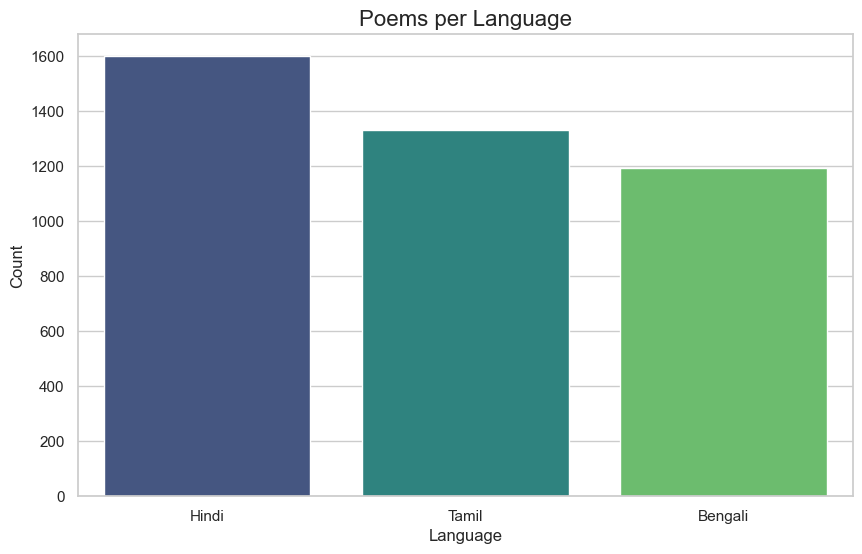

In [5]:
lang_counts = df['Source'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=lang_counts.index, y=lang_counts.values, palette='viridis')
plt.title('Poems per Language', fontsize=16)
plt.xlabel('Language', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

## 3. Label Distribution (VERY IMPORTANT)
**Objective**: highlight class imbalance to justify Macro F1 evaluation.
Displaying Top 15 labels in plot, full table below.

/var/folders/96/r1xph1zx3pz34nbqv3j9t8kw0000gn/T/ipykernel_89664/814123108.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_labels.index, y=top_15_labels.values, palette='magma')


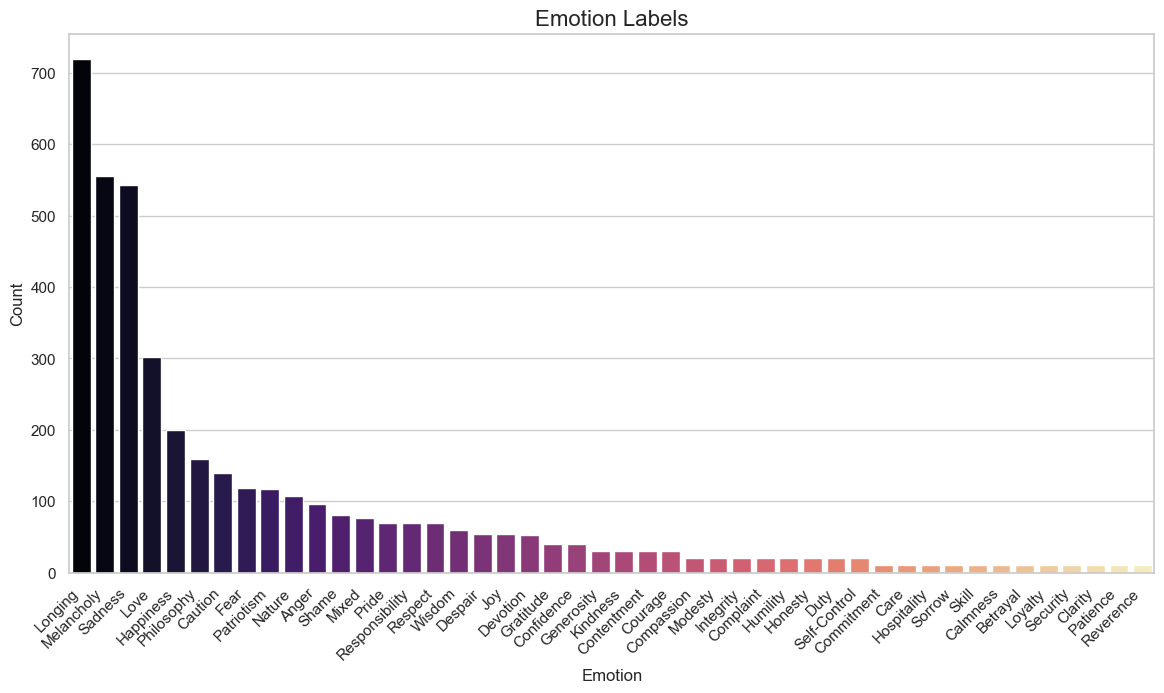

Full Label Counts:
Primary
Longing           719
Melancholy        555
Sadness           543
Love              302
Happiness         200
Philosophy        159
Caution           140
Fear              119
Patriotism        117
Nature            107
Anger              96
Shame              80
Mixed              76
Pride              70
Responsibility     70
Respect            70
Wisdom             60
Despair            54
Joy                54
Devotion           53
Gratitude          40
Confidence         40
Generosity         30
Kindness           30
Contentment        30
Courage            30
Compassion         20
Modesty            20
Integrity          20
Complaint          20
Humility           20
Honesty            20
Duty               20
Self-Control       20
Commitment         10
Care               10
Hospitality        10
Sorrow             10
Skill              10
Calmness           10
Betrayal           10
Loyalty            10
Security           10
Clarity            10
Patie

In [16]:
label_counts = df['Primary'].value_counts()
top_15_labels = label_counts.head(50)

plt.figure(figsize=(14, 7))
sns.barplot(x=top_15_labels.index, y=top_15_labels.values, palette='magma')
plt.title('Emotion Labels', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# Full Table
print("Full Label Counts:")
print(label_counts)

## 4. Long-Tail Label Visualization (SMART)
**Objective**: Demonstrate the difficulty of the task (many labels have few samples).

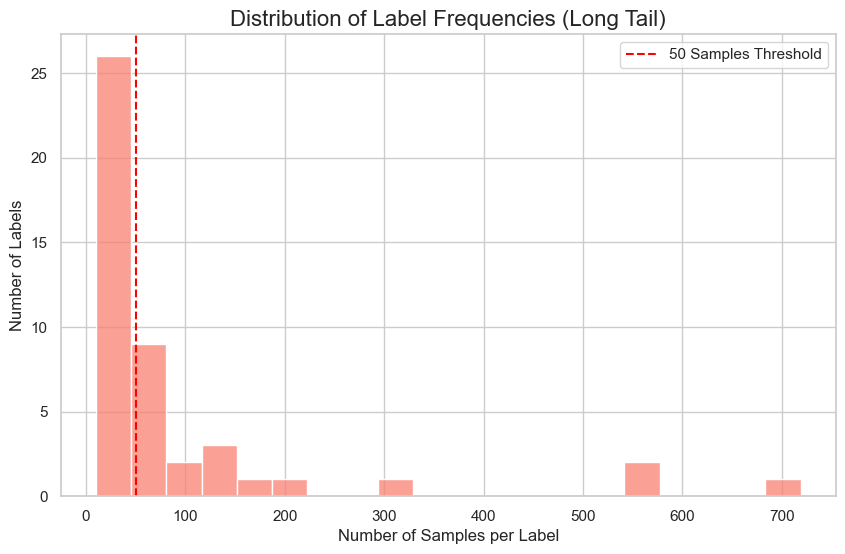

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(label_counts, bins=20, kde=False, color='salmon')
plt.title('Distribution of Label Frequencies (Long Tail)', fontsize=16)
plt.xlabel('Number of Samples per Label', fontsize=12)
plt.ylabel('Number of Labels', fontsize=12)
plt.axvline(50, color='red', linestyle='--', label='50 Samples Threshold')
plt.legend()
plt.show()

## 5. Poem Length Distribution (MANDATORY)
**Objective**: Justify max sequence length (128/256).

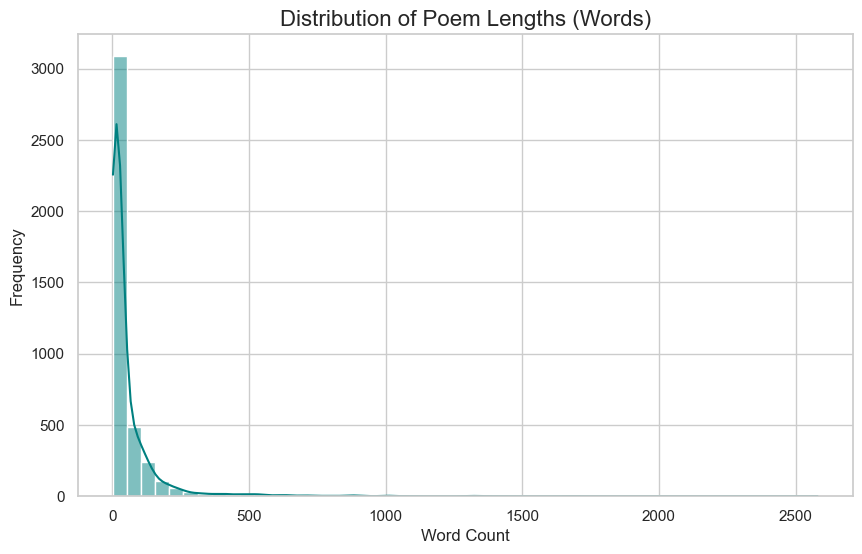

In [8]:
# Calculate word count if not present (though it should be from preprocessing)
if 'word_count' not in df.columns:
    df['word_count'] = df['cleaned_poem'].astype(str).str.split().str.len()

plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=50, kde=True, color='teal')
plt.title('Distribution of Poem Lengths (Words)', fontsize=16)
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

## 6. Poem Length by Language (CLEAN & IMPRESSIVE)
**Objective**: Reveal language-specific structures.

/var/folders/96/r1xph1zx3pz34nbqv3j9t8kw0000gn/T/ipykernel_89664/1674019731.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Source', y='word_count', data=df, palette='Set2')


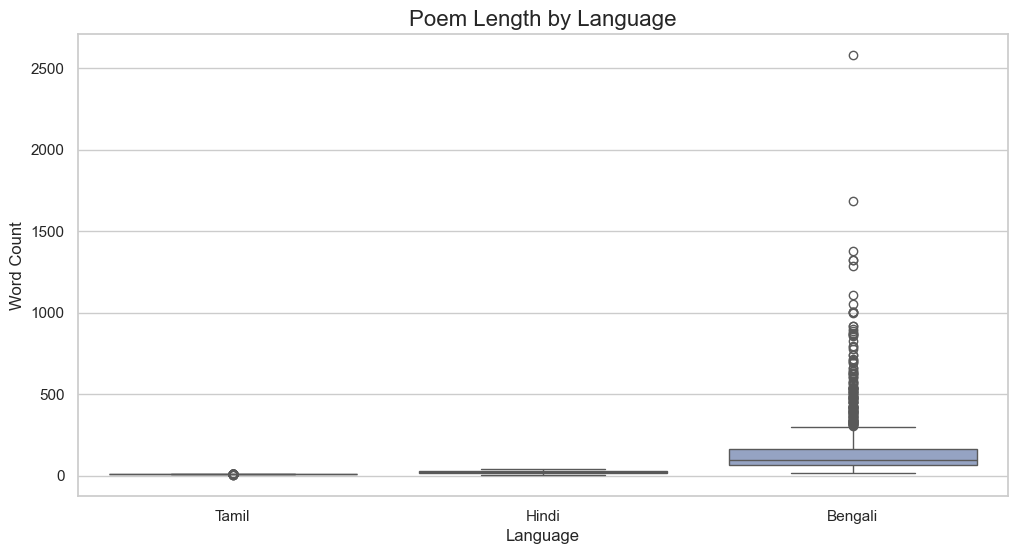

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Source', y='word_count', data=df, palette='Set2')
plt.title('Poem Length by Language', fontsize=16)
plt.xlabel('Language', fontsize=12)
plt.ylabel('Word Count', fontsize=12)
plt.show()

## 7. Label vs Language Heatmap (OPTIONAL BUT STRONG)
**Objective**: Show emotion dominance per language.

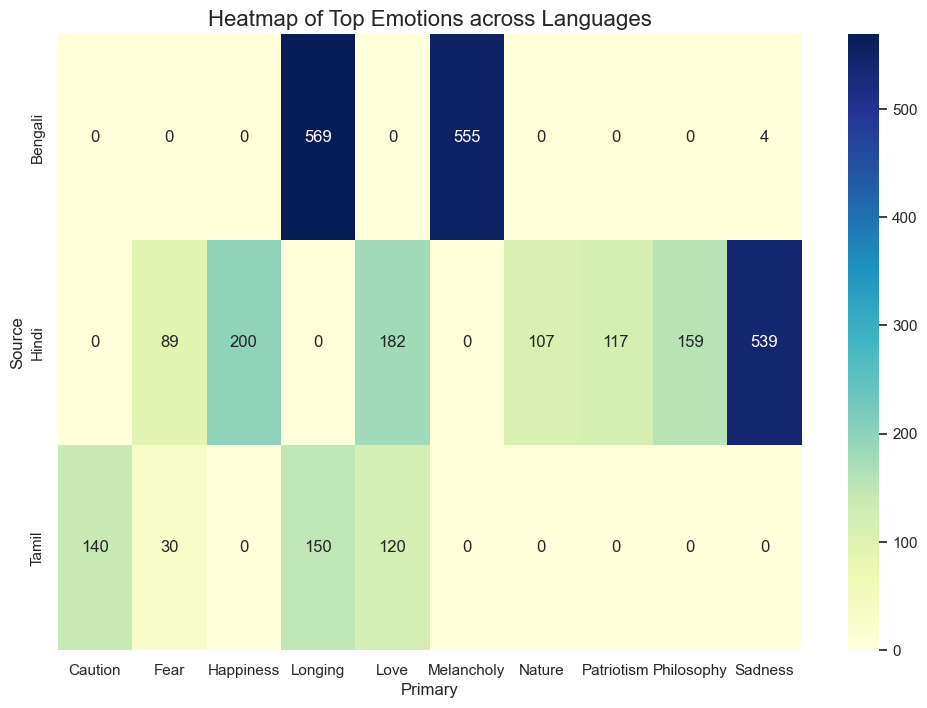

In [10]:
# Select top 10 labels for readability
top_labels = df['Primary'].value_counts().head(10).index
heatmap_data = df[df['Primary'].isin(top_labels)]

cross_tab = pd.crosstab(heatmap_data['Source'], heatmap_data['Primary'])

plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap of Top Emotions across Languages', fontsize=16)
plt.show()

## 8. Data Previews
**Objective**: Clean table views.

In [12]:
display(df.head())
print("\nValue Counts Head:")
print(df['Primary'].value_counts().head(10))

,Sl.No.,Poem,Source,Primary,cleaned_poem,script_match,word_count
0,1,அகர முதல எழுத்தெல்லாம் ஆதி பகவன் முதற்றே உலகு.,Tamil,Reverence,அகர முதல எழுத்தெல்லாம் ஆதி பகவன் முதற்றே உலகு.,True,7
1,2,கற்றதனால் ஆய பயனென்கொல் வாலறிவன் நற்றாள் தொழாஅ...,Tamil,Reverence,கற்றதனால் ஆய பயனென்கொல் வாலறிவன் நற்றாள் தொழாஅ...,True,7
2,3,மலர்மிசை ஏகினான் மாணடி சேர்ந்தார் நிலமிசை நீடு...,Tamil,Reverence,மலர்மிசை ஏகினான் மாணடி சேர்ந்தார் நிலமிசை நீடு...,True,7
3,4,வேண்டுதல்வேண் டாமை இலானடி சேர்ந்தார்க்கு யாண்ட...,Tamil,Reverence,வேண்டுதல்வேண் டாமை இலானடி சேர்ந்தார்க்கு யாண்ட...,True,7
4,5,இருள்சேர் இருவினையும் சேரா இறைவன் பொருள்சேர் ப...,Tamil,Reverence,இருள்சேர் இருவினையும் சேரா இறைவன் பொருள்சேர் ப...,True,7



Value Counts Head:
Primary
Longing       719
Melancholy    555
Sadness       543
Love          302
Happiness     200
Philosophy    159
Caution       140
Fear          119
Patriotism    117
Nature        107
Name: count, dtype: int64
